# 1D Cahn–Hilliard Equation

## 1. Physical Motivation
The **Cahn–Hilliard equation** models **phase separation** and **coarsening** in systems where the order parameter is **conserved** (e.g., composition $c(x,t)$ in a binary alloy).  
It describes the **diffusion of composition driven by chemical potential gradients**, where interfaces are **diffuse** rather than sharp.

---

## 2. Free Energy Functional
We start with a free energy functional for the composition field $c(x,t)$:

$$
F[c] = \int \left[ f(c) + \frac{\kappa}{2} \left( \frac{\partial c}{\partial x} \right)^2 \right] dx
$$

- $f(c)$: **bulk free energy density** (double-well form for two stable phases)  
- $\kappa$: **gradient energy coefficient**, penalizing sharp interfaces

A common choice for the bulk term is the double-well potential:
$$
f(c) = \frac{1}{4} \left(c^2 - 1\right)^2
$$

---

## 3. Chemical Potential
The **chemical potential** is the variational derivative of $F$:

$$
\mu(x,t) = \frac{\delta F}{\delta c} 
= f'(c) - \kappa \frac{\partial^2 c}{\partial x^2}
$$

For the double-well potential:
$$
f'(c) = c^3 - c
$$
so:
$$
\mu = c^3 - c - \kappa \frac{\partial^2 c}{\partial x^2}
$$

---

## 4. Conservation Law and Dynamics
Since composition is conserved, we write a continuity equation:

$$
\frac{\partial c}{\partial t} = - \frac{\partial J}{\partial x}
$$

where the flux follows a generalized Fick’s law:
$$
J = -M \frac{\partial \mu}{\partial x}
$$

Here $M$ is the **mobility** (assumed constant). Substituting $J$ gives:

$$
\frac{\partial c}{\partial t} 
= M \frac{\partial^2 \mu}{\partial x^2}
$$

Replacing $\mu$:
$$
\frac{\partial c}{\partial t} 
= M \frac{\partial^2}{\partial x^2} \left[ c^3 - c - \kappa \frac{\partial^2 c}{\partial x^2} \right]
$$

This is the **1D Cahn–Hilliard equation**.

---

## 5. Key Properties
- **Fourth-order PDE**: due to the $\nabla^4 c$ term from the gradient energy.
- **Conservation of total $c$**:  
  $\frac{d}{dt} \int c \, dx = 0$
- **Interface width** $\sim \sqrt{\kappa}$
- **Domain coarsening**: characteristic length grows as $t^{1/3}$ in late-stage phase separation.

---

## 6. Numerical Implementation (Spectral Method)
For periodic boundary conditions, FFT simplifies the derivatives:
$$
\mathcal{F} \left[ \frac{\partial^2 c}{\partial x^2} \right] = -k^2 \hat{c}
$$
$$
\mathcal{F} \left[ \frac{\partial^4 c}{\partial x^4} \right] = k^4 \hat{c}
$$

A **semi-implicit time-stepping** scheme:
$$
\hat{c}^{n+1} = 
\frac{\hat{c}^n - \Delta t \, M \, k^2 \, \widehat{c^3 - c} }
     {1 + \Delta t \, M \, \kappa \, k^4}
$$

This avoids instability that occurs in explicit schemes for fourth-order PDEs.

---

## 7. Minimal 1D Implementation (NumPy/FFT)
```python
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 256
L = 1.0
dx = L / N
dt = 1e-5
nsteps = 2000
M = 1.0
kappa = 1e-2

# Grid & wave numbers
x = np.linspace(0, L, N, endpoint=False)
k = 2 * np.pi * np.fft.fftfreq(N, d=dx)
k2 = k**2
k4 = k2**2

# Initial condition
c = 0.5 + 0.01 * (2*np.random.rand(N) - 1)

# Time stepping
for step in range(nsteps):
    mu_hat = np.fft.fft(c**3 - c)  # Nonlinear term
    c_hat = (np.fft.fft(c) - dt * M * k2 * mu_hat) / (1 + dt * M * kappa * k4)
    c = np.fft.ifft(c_hat).real
    if step % 200 == 0:
        plt.plot(x, c, label=f"t={step*dt:.4f}")

plt.xlabel("x")
plt.ylabel("c(x)")
plt.legend()
plt.title("1D Cahn–Hilliard Spinodal Decomposition")
plt.show()


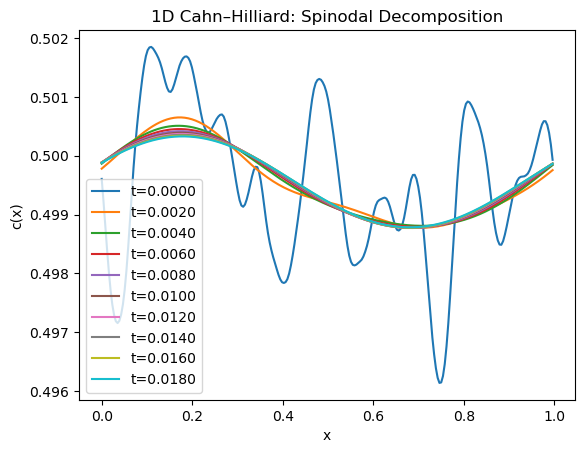

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 256        # grid points
L = 1.0        # domain length
dx = L / N
dt = 1e-5      # time step
nsteps = 2000  # number of steps
M = 1.0        # mobility
kappa = 1e-2   # gradient energy coefficient

# Grid and wave numbers for FFT
x = np.linspace(0, L, N, endpoint=False)
k = 2 * np.pi * np.fft.fftfreq(N, d=dx)
k2 = k**2
k4 = k2**2

# Initial condition: small random fluctuations around mean c0
c = 0.5 + 0.01 * (2*np.random.rand(N) - 1)

# Free energy derivative df/dc = c^3 - c (double-well potential)
def mu(c):
    return c**3 - c - kappa * np.fft.ifft(k2 * np.fft.fft(c)).real

# Time integration (semi-implicit spectral)
for step in range(nsteps):
    c_hat = np.fft.fft(c)
    mu_hat = np.fft.fft(c**3 - c)
    c_hat = (c_hat - dt * M * k2 * mu_hat) / (1 + dt * M * kappa * k4)
    c = np.fft.ifft(c_hat).real
    if step % 200 == 0:
        plt.plot(x, c, label=f"t={step*dt:.4f}")

plt.xlabel("x")
plt.ylabel("c(x)")
plt.legend()
plt.title("1D Cahn–Hilliard: Spinodal Decomposition")
plt.show()


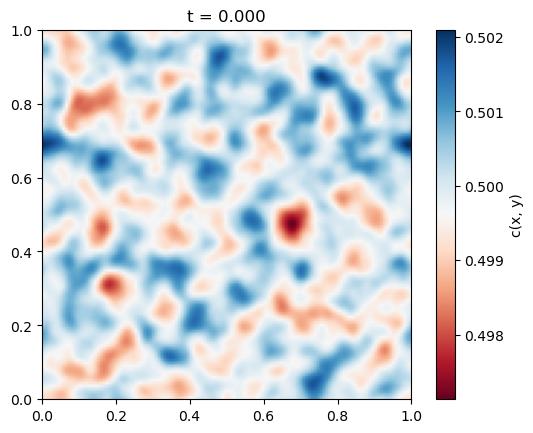

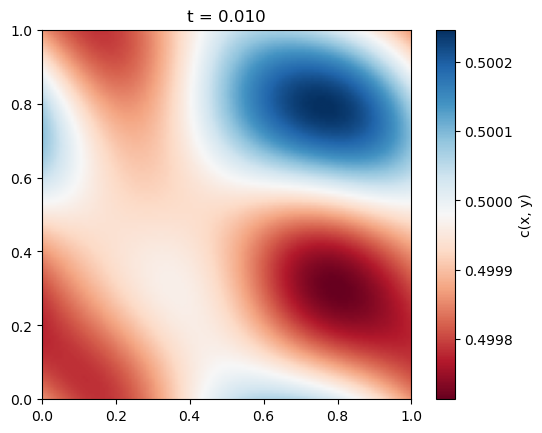

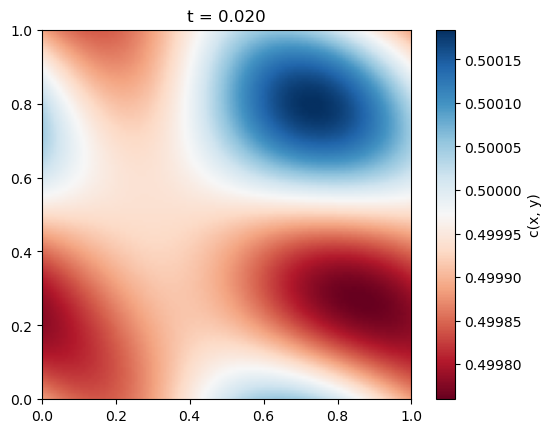

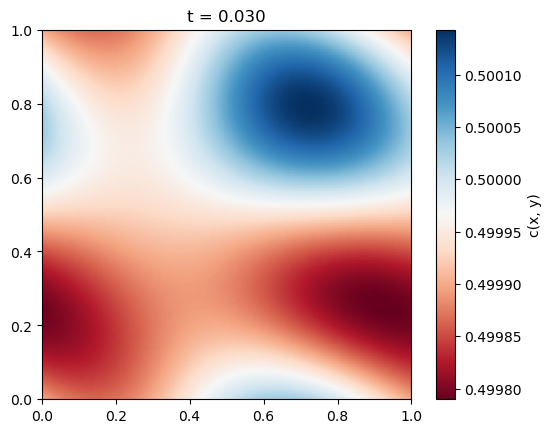

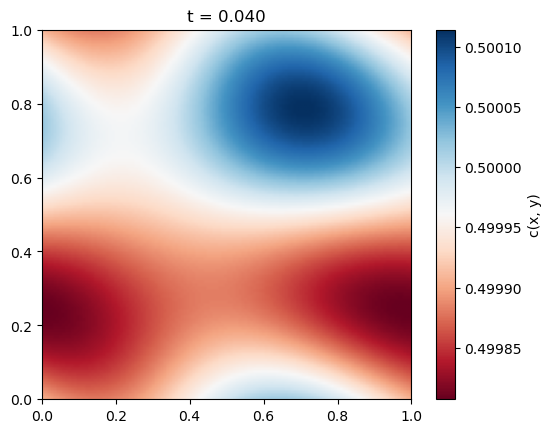

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
N = 128        # grid points per side
L = 1.0        # domain length
dx = L / N
dt = 1e-5      # time step
nsteps = 5000  # number of steps
M = 1.0        # mobility
kappa = 1e-2   # gradient energy coefficient

# ----------------------------
# Grid and wave numbers
# ----------------------------
kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(N, d=dx)
kx2, ky2 = np.meshgrid(kx**2, ky**2, indexing="ij")
k2 = kx2 + ky2
k4 = k2**2

# ----------------------------
# Initial condition
# ----------------------------
c = 0.5 + 0.01 * (2*np.random.rand(N, N) - 1)

# ----------------------------
# Time-stepping loop
# ----------------------------
for step in range(nsteps):
    # Nonlinear chemical potential term
    mu_hat = np.fft.fft2(c**3 - c)
    # Semi-implicit update
    c_hat = (np.fft.fft2(c) - dt * M * k2 * mu_hat) / (1 + dt * M * kappa * k4)
    # Transform back to real space
    c = np.fft.ifft2(c_hat).real

    # Visualization every 1000 steps
    if step % 1000 == 0:
        plt.imshow(c, cmap="RdBu", origin="lower", extent=[0, L, 0, L])
        plt.colorbar(label="c(x, y)")
        plt.title(f"t = {step*dt:.3f}")
        plt.show()
